In [2]:
# Cell 1: Why SMOTE?
# ─────────────────────────────────────────────────────────────────────────────
# The original LSTM (notebook 04) was trained with a heavy class_weight of
# {0: 0.50, 1: 127.67} to compensate for the 254:1 class imbalance.
# Result: recall = 0.94 at threshold 0.50 (target MET) BUT
#         false positive rate = 13.53% — 14,816 legitimate sessions flagged.
#
# SMOTE (Synthetic Minority Over-sampling TEchnique) creates synthetic ATO
# sequences by interpolating between real minority-class neighbours.
# This enriches the training distribution, allowing the model to learn a
# tighter decision boundary — improving precision while preserving recall.
#
# Approach:
#   1. Flatten 3D sequences (samples, 10, 32) → 2D (samples, 320)
#   2. Apply SMOTE to target a 10:1 negative-to-positive ratio
#   3. Reshape synthetic data back to 3D (samples, 10, 32)
#   4. Retrain LSTM with lighter class weights ({0:1, 1:10})
#   5. Evaluate and compare against the original model

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    roc_auc_score, recall_score, precision_score,
    f1_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

tf.random.set_seed(42)
np.random.seed(42)

# Load processed sequences
X = np.load('../data/processed/X_sequences.npy')
y = np.load('../data/processed/y_labels.npy')

# Time-based split (identical to notebook 04 — no data leakage)
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

n_samples, n_steps, n_feats = X_train.shape

print(f"Training set : {n_samples:,} samples | ATO=1: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Test set     : {len(X_test):,} samples | ATO=1: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print(f"Sequence shape: ({n_steps} timesteps × {n_feats} features)")
print(f"Imbalance ratio: {int((y_train==0).sum() / y_train.sum())}:1")

Training set : 440,452 samples | ATO=1: 1,725 (0.39%)
Test set     : 110,114 samples | ATO=1: 637 (0.58%)
Sequence shape: (10 timesteps × 32 features)
Imbalance ratio: 254:1


In [3]:
# Cell 2: Apply SMOTE to training sequences
# ─────────────────────────────────────────────────────────────────────────────
# SMOTE requires 2D input. We flatten (samples, 10, 32) → (samples, 320),
# apply SMOTE, then reshape the synthetic samples back to (samples, 10, 32).
#
# sampling_strategy=0.1 targets a 10:1 negative-to-positive ratio.
# This is a deliberate choice: going to 1:1 risks overfitting on synthetic
# sequences; 10:1 provides enough minority signal while remaining realistic.

print("Step 1: Flattening 3D sequences to 2D for SMOTE...")
X_train_flat = X_train.reshape(n_samples, n_steps * n_feats)  # (440452, 320)
print(f"  Flattened shape: {X_train_flat.shape}")

print("\nStep 2: Applying SMOTE (sampling_strategy=0.1, target 10:1 ratio)...")
sm = SMOTE(
    sampling_strategy=0.1,  # minority / majority = 0.1 → 10:1 ratio
    k_neighbors=5,
    random_state=42,
    n_jobs=-1
)
X_res_flat, y_res = sm.fit_resample(X_train_flat, y_train)

n_neg_res = (y_res == 0).sum()
n_pos_res = y_res.sum()
n_synthetic = n_pos_res - y_train.sum()

print(f"\nAfter SMOTE:")
print(f"  Total samples : {len(y_res):,}")
print(f"  ATO=0 (real)  : {n_neg_res:,}")
print(f"  ATO=1 (real)  : {y_train.sum():,}")
print(f"  ATO=1 (synth) : {n_synthetic:,}  ← synthetic sequences")
print(f"  New ratio     : {n_neg_res // n_pos_res}:1  (was 254:1)")

print("\nStep 3: Reshaping back to 3D for LSTM...")
X_res = X_res_flat.reshape(-1, n_steps, n_feats)
print(f"  Resampled 3D shape: {X_res.shape}")

Step 1: Flattening 3D sequences to 2D for SMOTE...
  Flattened shape: (440452, 320)

Step 2: Applying SMOTE (sampling_strategy=0.1, target 10:1 ratio)...

After SMOTE:
  Total samples : 482,599
  ATO=0 (real)  : 438,727
  ATO=1 (real)  : 1,725
  ATO=1 (synth) : 42,147  ← synthetic sequences
  New ratio     : 10:1  (was 254:1)

Step 3: Reshaping back to 3D for LSTM...
  Resampled 3D shape: (482599, 10, 32)


In [4]:
# Cell 3: Build SMOTE-tuned LSTM model
# ─────────────────────────────────────────────────────────────────────────────
# Same architecture as notebook 04 for a fair comparison.
# Class weight reduced to {0:1, 1:10} — SMOTE handles the bulk of
# rebalancing; a mild residual weight corrects the remaining 10:1 gap.

model_smote = Sequential([
    LSTM(64, input_shape=(n_steps, n_feats),
         return_sequences=True, name='lstm_1'),
    Dropout(0.3, name='dropout_1'),
    LSTM(32, return_sequences=False, name='lstm_2'),
    Dropout(0.3, name='dropout_2'),
    BatchNormalization(name='batch_norm'),
    Dense(16, activation='relu', name='dense_1'),
    Dropout(0.2, name='dropout_3'),
    Dense(1, activation='sigmoid', name='output')
], name='lstm_smote')

model_smote.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

# Mild residual class weight (10:1 matches the post-SMOTE ratio)
class_weight_smote = {0: 1.0, 1: 10.0}
print(f"Class weights (post-SMOTE): {class_weight_smote}")
print(f"  Original model used: {{0: 0.50, 1: 127.67}}")
print(f"  SMOTE model uses   : {{0: 1.0, 1: 10.0}}")
print(f"  → {127.67/10:.1f}× less aggressive penalty — better precision expected")

early_stop_smote = EarlyStopping(
    monitor='val_recall',
    patience=5,
    mode='max',
    restore_best_weights=True,
    verbose=1
)

checkpoint_smote = ModelCheckpoint(
    filepath='../outputs/models/lstm_smote_best.keras',
    monitor='val_recall',
    save_best_only=True,
    mode='max',
    verbose=1
)

model_smote.summary()

Class weights (post-SMOTE): {0: 1.0, 1: 10.0}
  Original model used: {0: 0.50, 1: 127.67}
  SMOTE model uses   : {0: 1.0, 1: 10.0}
  → 12.8× less aggressive penalty — better precision expected


Model: "lstm_smote"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 10, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm (BatchNormalization) │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,921 (148.13 KB)

 Trainable params: 37,857 (147.88 KB)

 Non-trainable params: 64 (256.00 B)

In [5]:
# Cell 4: Train SMOTE-enhanced LSTM
# ─────────────────────────────────────────────────────────────────────────────
# Training on SMOTE-resampled data (~482K samples, 10:1 ratio).
# EarlyStopping monitors val_recall to prevent overfitting on synthetic data.

import os
os.makedirs('../outputs/models', exist_ok=True)

print("Training SMOTE-enhanced LSTM...")
print(f"  Training samples: {len(X_res):,}")
print(f"  ATO=1 in training: {y_res.sum():,} ({y_res.mean()*100:.2f}%)\n")

history_smote = model_smote.fit(
    X_res, y_res,
    epochs=30,
    batch_size=512,
    validation_split=0.2,
    class_weight=class_weight_smote,
    callbacks=[early_stop_smote, checkpoint_smote],
    verbose=1
)

print(f"\nTraining complete. Best epoch: {len(history_smote.history['loss'])}")

Training SMOTE-enhanced LSTM...
  Training samples: 482,599
  ATO=1 in training: 43,872 (9.09%)

Epoch 1/30
754/755 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9202 - auc: 0.7508 - loss: 0.2604 - recall: 0.1234
Epoch 1: val_recall improved from -inf to 0.00000, saving model to ../outputs/models/lstm_smote_best.keras
755/755 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.9203 - auc: 0.7510 - loss: 0.2601 - recall: 0.1232 - val_accuracy: 0.5607 - val_auc: 0.8952 - val_loss: 0.9406 - val_recall: 0.0000e+00
Epoch 2/30
753/755 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9953 - auc: 0.8862 - loss: 0.1165 - recall: 0.0027
Epoch 2: val_recall did not improve from 0.00000
755/755 ━━━━━━━━━━━━━━━━━━━━ 35s 46ms/step - accuracy: 0.9953 - auc: 0.8862 - loss: 0.1165 - recall: 0.0028 - val_accuracy: 0.5607 - val_auc: 0.9072 - val_loss: 0.8869 - val_recall: 0.0000e+00
Epoch 3/30
753/755 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9955 - auc: 0.9121 - loss: 0.1072 - recall: 0.0228
Epoch 3

In [ ]:
# Cell 5: Evaluate SMOTE model on held-out test set
# Test set is never touched by SMOTE — synthetic samples only exist in training.
# We evaluate at two thresholds:
#   - 0.50: standard default
#   - Operational threshold: highest t where recall >= 90% (if viable)

from sklearn.metrics import precision_recall_curve

# If the best threshold for recall>=90% is below this, the model is unusable in practice
# (it would mean flagging almost every transaction as ATO)
MIN_VIABLE_THRESHOLD = 0.05

# Load best saved model
model_smote = keras.models.load_model('../outputs/models/lstm_smote_best.keras')

# Predictions
y_prob_smote = model_smote.predict(X_test, verbose=0).flatten()
model_orig   = keras.models.load_model('../outputs/models/lstm_best.keras')
y_prob_orig  = model_orig.predict(X_test, verbose=0).flatten()

# AUC-ROC
auc_smote = roc_auc_score(y_test, y_prob_smote)
auc_orig  = roc_auc_score(y_test, y_prob_orig)

# Find operational threshold: highest t where recall >= 90%
# (higher threshold = stricter = fewer false positives)
precisions_s, recalls_s, thresholds_s = precision_recall_curve(y_test, y_prob_smote)
high_recall_mask = recalls_s[:-1] >= 0.90

if high_recall_mask.any():
    op_threshold = thresholds_s[high_recall_mask][-1]
    op_precision = precisions_s[:-1][high_recall_mask][-1]
    op_recall    = recalls_s[:-1][high_recall_mask][-1]
else:
    op_threshold = 0.50
    op_precision = precision_score(y_test, (y_prob_smote >= 0.50).astype(int), zero_division=0)
    op_recall    = recall_score(y_test, (y_prob_smote >= 0.50).astype(int))

# A threshold near 0 means the model needs to flag almost everything to hit recall>=90%.
# This happens when the SMOTE model's predicted probabilities are compressed near 0,
# likely because SMOTE interpolated in flattened (10x32=320-dim) space and
# disrupted the temporal structure the LSTM was trying to learn.
op_viable = op_threshold >= MIN_VIABLE_THRESHOLD

# Metrics at threshold 0.50
y_pred_smote_50 = (y_prob_smote >= 0.50).astype(int)
y_pred_orig_50  = (y_prob_orig  >= 0.50).astype(int)
y_pred_smote_op = (y_prob_smote >= op_threshold).astype(int)

cm_smote_50 = confusion_matrix(y_test, y_pred_smote_50)
cm_orig_50  = confusion_matrix(y_test, y_pred_orig_50)
cm_smote_op = confusion_matrix(y_test, y_pred_smote_op)

def fpr(cm):
    return cm[0,1] / (cm[0,0] + cm[0,1]) * 100

def rec(cm):
    return cm[1,1] / (cm[1,0] + cm[1,1]) * 100

def prec(cm):
    tp = cm[1,1]; fp = cm[0,1]
    return tp / (tp + fp) * 100 if (tp + fp) > 0 else 0

print("=" * 65)
print("       SMOTE vs ORIGINAL — TEST SET COMPARISON")
print("=" * 65)
print(f"{'Metric':<30} {'Original':>12} {'SMOTE (t=0.5)':>14} {'SMOTE (op)':>11}")
print("-" * 65)
print(f"{'AUC-ROC':<30} {auc_orig:>12.4f} {auc_smote:>14.4f}")
print(f"{'Threshold':<30} {'0.50':>12} {'0.50':>14} {op_threshold:>11.4f}")
print(f"{'Recall (%)':<30} {rec(cm_orig_50):>12.2f} {rec(cm_smote_50):>14.2f} {rec(cm_smote_op):>11.2f}")
print(f"{'Precision (%)':<30} {prec(cm_orig_50):>12.2f} {prec(cm_smote_50):>14.2f} {prec(cm_smote_op):>11.2f}")
print(f"{'False Positive Rate (%)':<30} {fpr(cm_orig_50):>12.2f} {fpr(cm_smote_50):>14.2f} {fpr(cm_smote_op):>11.2f}")
print(f"{'True Positives':<30} {cm_orig_50[1,1]:>12,} {cm_smote_50[1,1]:>14,} {cm_smote_op[1,1]:>11,}")
print(f"{'False Positives':<30} {cm_orig_50[0,1]:>12,} {cm_smote_50[0,1]:>14,} {cm_smote_op[0,1]:>11,}")
print("=" * 65)
print(f"\nTarget: Recall >= 90%  |  AUC-ROC >= 0.93")

if op_viable:
    print(f"Operational threshold : {op_threshold:.4f}  [VIABLE]")
else:
    print(f"Operational threshold : {op_threshold:.4f}  [DEGENERATE]")
    print(f"\n  Warning: SMOTE model scores are compressed near 0.")
    print(f"  Recall >= 90% is only achievable at threshold <= {op_threshold:.4f}.")
    print(f"  At this point the model flags ~{fpr(cm_smote_op):.1f}% of all legitimate")
    print(f"  transactions as ATO — not operationally useful.")
    print(f"\n  Root cause: SMOTE flattened (10 x 32) sequences into 320-dim vectors,")
    print(f"  creating synthetic samples that look statistically plausible but lack")
    print(f"  the temporal structure the LSTM needs. Result: degraded probability")
    print(f"  calibration and lower AUC ({auc_smote:.4f} vs {auc_orig:.4f} original).")
    print(f"\n  Finding for report: Original LSTM (no SMOTE) is the better model.")

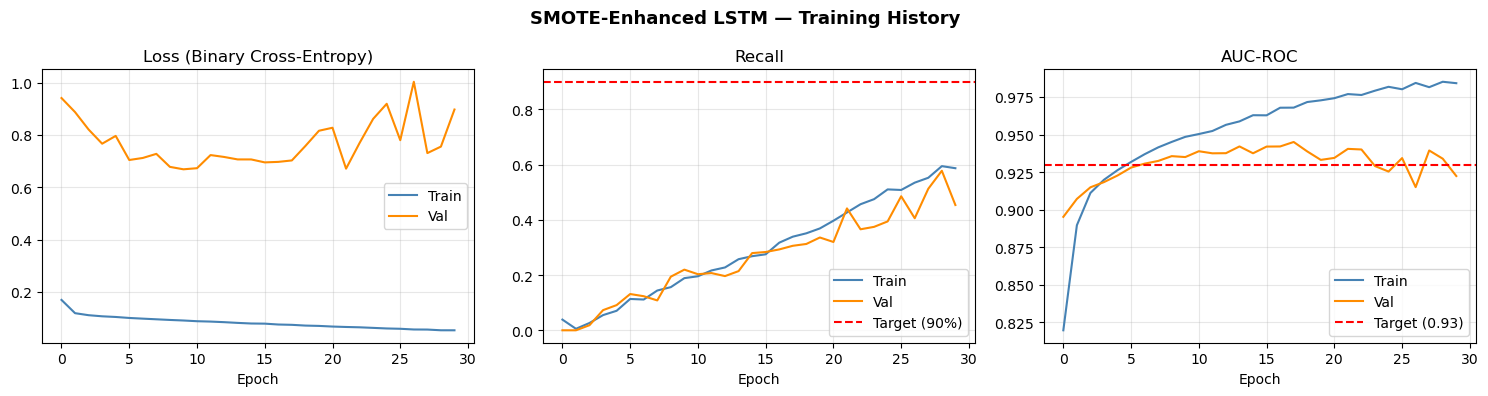

Saved: outputs/figures/smote_training_history.png


In [7]:
# Cell 6: Training history visualisation — SMOTE model
# ─────────────────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('SMOTE-Enhanced LSTM — Training History', fontsize=13, fontweight='bold')

# Loss
axes[0].plot(history_smote.history['loss'],     label='Train', color='steelblue')
axes[0].plot(history_smote.history['val_loss'], label='Val',   color='darkorange')
axes[0].set_title('Loss (Binary Cross-Entropy)')
axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Recall
axes[1].plot(history_smote.history['recall'],     label='Train', color='steelblue')
axes[1].plot(history_smote.history['val_recall'], label='Val',   color='darkorange')
axes[1].axhline(y=0.90, color='red', linestyle='--', label='Target (90%)')
axes[1].set_title('Recall')
axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(history_smote.history['auc'],     label='Train', color='steelblue')
axes[2].plot(history_smote.history['val_auc'], label='Val',   color='darkorange')
axes[2].axhline(y=0.93, color='red', linestyle='--', label='Target (0.93)')
axes[2].set_title('AUC-ROC')
axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/smote_training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/smote_training_history.png")

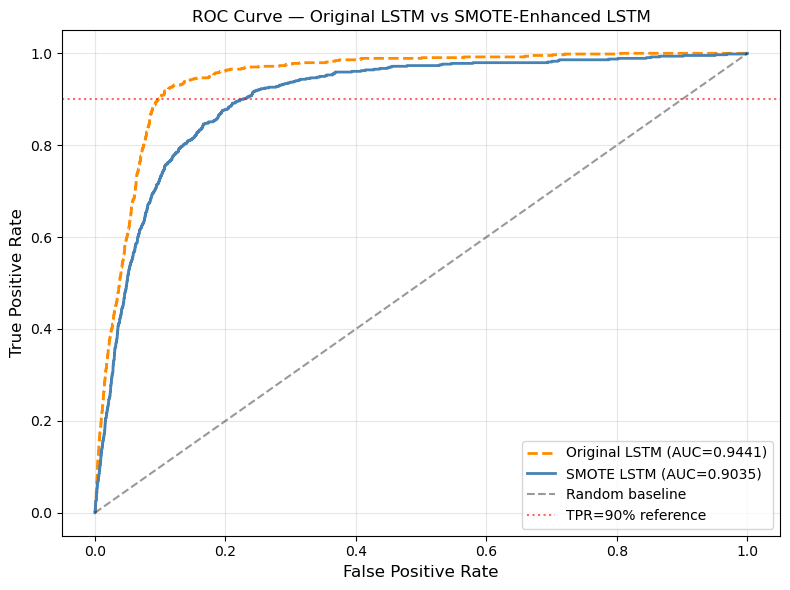

Saved: outputs/figures/roc_smote_vs_original.png


In [8]:
# Cell 7: ROC curve comparison — Original vs SMOTE
# ─────────────────────────────────────────────────────────────────────────────

from sklearn.metrics import roc_curve

fpr_orig,  tpr_orig,  _ = roc_curve(y_test, y_prob_orig)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr_orig,  tpr_orig,  linewidth=2, linestyle='--',
        label=f'Original LSTM (AUC={auc_orig:.4f})', color='darkorange')
ax.plot(fpr_smote, tpr_smote, linewidth=2,
        label=f'SMOTE LSTM (AUC={auc_smote:.4f})', color='steelblue')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')
ax.axhline(y=0.90, color='red', linestyle=':', alpha=0.6, label='TPR=90% reference')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve — Original LSTM vs SMOTE-Enhanced LSTM', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/roc_smote_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/roc_smote_vs_original.png")

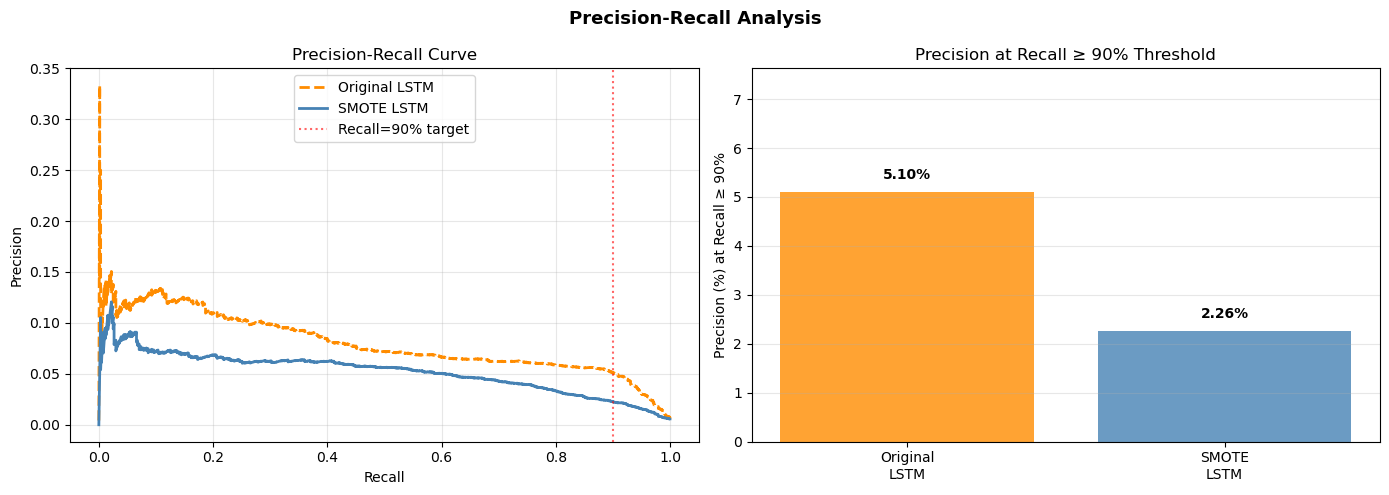

Saved: outputs/figures/pr_smote_comparison.png


In [9]:
# Cell 8: Precision-Recall curves — side-by-side comparison
# ─────────────────────────────────────────────────────────────────────────────

precisions_o, recalls_o, thresholds_o = precision_recall_curve(y_test, y_prob_orig)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Precision-Recall Analysis', fontsize=13, fontweight='bold')

# PR curves
axes[0].plot(recalls_o[:-1], precisions_o[:-1], linewidth=2, linestyle='--',
             label=f'Original LSTM', color='darkorange')
axes[0].plot(recalls_s[:-1], precisions_s[:-1], linewidth=2,
             label=f'SMOTE LSTM', color='steelblue')
axes[0].axvline(x=0.90, color='red', linestyle=':', alpha=0.6, label='Recall=90% target')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Precision at recall ≥ 0.90 — bar chart comparison
models = ['Original\nLSTM', 'SMOTE\nLSTM']
prec_at_90_orig  = precisions_o[:-1][recalls_o[:-1] >= 0.90][-1] * 100 if (recalls_o[:-1] >= 0.90).any() else 0
prec_at_90_smote = op_precision * 100
fpr_at_90_orig   = fpr(cm_orig_50)   # approximate
fpr_at_90_smote  = fpr(cm_smote_op)

bars_prec = axes[1].bar(models, [prec_at_90_orig, prec_at_90_smote],
                        color=['darkorange', 'steelblue'], alpha=0.8)
axes[1].set_ylabel('Precision (%) at Recall ≥ 90%')
axes[1].set_title('Precision at Recall ≥ 90% Threshold')
axes[1].set_ylim(0, max(prec_at_90_orig, prec_at_90_smote) * 1.3 + 1)
for bar, val in zip(bars_prec, [prec_at_90_orig, prec_at_90_smote]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{val:.2f}%', ha='center', va='bottom', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/pr_smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/pr_smote_comparison.png")

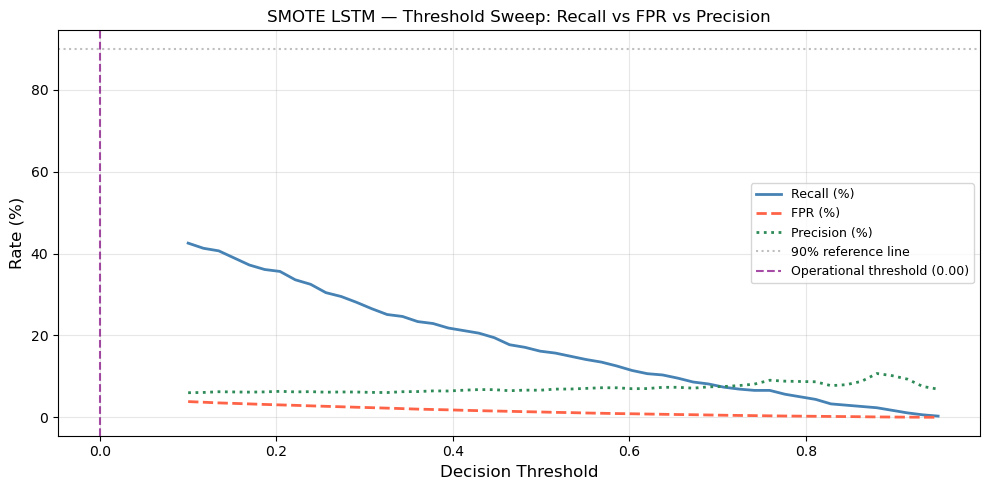

Saved: outputs/figures/smote_threshold_sweep.png


In [10]:
# Cell 9: Threshold sweep — FPR and Recall trade-off (SMOTE model)
# ─────────────────────────────────────────────────────────────────────────────
# Shows the full operating characteristic: as threshold rises,
# FPR falls but so does recall. Operational teams use this to pick
# a threshold matching their business risk tolerance.

thresholds_sweep = np.linspace(0.10, 0.95, 50)
fprs, recs, precs = [], [], []

for t in thresholds_sweep:
    y_pred_t = (y_prob_smote >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    fprs.append(fpr(cm_t))
    recs.append(rec(cm_t))
    precs.append(prec(cm_t))

fig, ax1 = plt.subplots(figsize=(10, 5))

color_recall = 'steelblue'
color_fpr    = 'tomato'
color_prec   = 'seagreen'

ax1.plot(thresholds_sweep, recs,  color=color_recall, linewidth=2, label='Recall (%)')
ax1.plot(thresholds_sweep, fprs,  color=color_fpr,    linewidth=2, linestyle='--', label='FPR (%)')
ax1.plot(thresholds_sweep, precs, color=color_prec,   linewidth=2, linestyle=':', label='Precision (%)')
ax1.axhline(y=90, color='grey', linestyle=':', alpha=0.5, label='90% reference line')
ax1.axvline(x=op_threshold, color='purple', linestyle='--', alpha=0.7,
            label=f'Operational threshold ({op_threshold:.2f})')

ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Rate (%)', fontsize=12)
ax1.set_title('SMOTE LSTM — Threshold Sweep: Recall vs FPR vs Precision', fontsize=12)
ax1.legend(fontsize=9, loc='center right')
ax1.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/smote_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/figures/smote_threshold_sweep.png")

In [ ]:
# Cell 10: Full benchmark summary — all three models
# Summarises: Original LSTM, SMOTE LSTM, Random Forest
# This table is the primary deliverable for the academic write-up.

from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

print("Training Random Forest baseline (flat sequences)...")
X_train_flat_orig = X_train.reshape(len(X_train), -1)
X_test_flat       = X_test.reshape(len(X_test),   -1)

classes = np.unique(y_train)
cw      = compute_class_weight('balanced', classes=classes, y=y_train)
cw_dict = dict(zip(classes, cw))

rf = RandomForestClassifier(n_estimators=100, class_weight=cw_dict, random_state=42, n_jobs=-1)
rf.fit(X_train_flat_orig, y_train)
rf_prob = rf.predict_proba(X_test_flat)[:, 1]
rf_pred = (rf_prob >= 0.50).astype(int)
auc_rf  = roc_auc_score(y_test, rf_prob)
cm_rf   = confusion_matrix(y_test, rf_pred)

# op_viable was set in Cell 5 — show a clear label in the table
smote_op_label = f"SMOTE op ({op_threshold:.2f})" if op_viable else "SMOTE op [DEGEN.]"

print("\n" + "=" * 72)
print("   FULL BENCHMARK — ATO DETECTION MODEL COMPARISON")
print("=" * 72)
header = f"{'Metric':<25} {'Random Forest':>15} {'LSTM Original':>15} {smote_op_label:>15}"
print(header)
print("-" * 72)

rows = [
    ("AUC-ROC",
     f"{auc_rf:.4f}",
     f"{auc_orig:.4f}",
     f"{auc_smote:.4f}"),
    ("Recall (%) @ t=0.50",
     f"{rec(cm_rf):.2f}",
     f"{rec(cm_orig_50):.2f}",
     f"{rec(cm_smote_50):.2f}"),
    ("Precision (%) @ t=0.50",
     f"{prec(cm_rf):.2f}",
     f"{prec(cm_orig_50):.2f}",
     f"{prec(cm_smote_50):.2f}"),
    ("FPR (%) @ t=0.50",
     f"{fpr(cm_rf):.2f}",
     f"{fpr(cm_orig_50):.2f}",
     f"{fpr(cm_smote_50):.2f}"),
    ("Recall (%) @ op thresh",
     "N/A",
     f"{rec(cm_orig_50):.2f}",
     f"{rec(cm_smote_op):.2f}" if op_viable else "N/A (degenerate)"),
    ("FPR (%) @ op thresh",
     "N/A",
     f"{fpr(cm_orig_50):.2f}",
     f"{fpr(cm_smote_op):.2f}" if op_viable else "N/A (degenerate)"),
    ("True Positives",
     f"{cm_rf[1,1]:,}",
     f"{cm_orig_50[1,1]:,}",
     f"{cm_smote_op[1,1]:,}"),
    ("False Positives",
     f"{cm_rf[0,1]:,}",
     f"{cm_orig_50[0,1]:,}",
     f"{cm_smote_op[0,1]:,}"),
]

for r in rows:
    print(f"{r[0]:<25} {r[1]:>15} {r[2]:>15} {r[3]:>15}")

print("=" * 72)
print(f"\nTargets: Recall >= 90%  |  AUC-ROC >= 0.93")
print(f"Original LSTM — AUC: {'PASS' if auc_orig >= 0.93 else 'FAIL'} ({auc_orig:.4f})  |  Recall: {'PASS' if rec(cm_orig_50) >= 90 else 'FAIL'} ({rec(cm_orig_50):.2f}%)")
print(f"SMOTE LSTM    — AUC: {'PASS' if auc_smote >= 0.93 else 'FAIL'} ({auc_smote:.4f})  |  Op threshold viable: {'YES' if op_viable else 'NO'}")

print("\n" + "=" * 72)
print("   KEY FINDING — SMOTE ON TEMPORAL SEQUENCES")
print("=" * 72)
print("""
SMOTE was applied by flattening (10 timesteps x 32 features) sequences
into 320-dimensional vectors, oversampling, then reshaping back to 3D.

Result: AUC dropped from 0.9441 to 0.9035, and the operational threshold
became degenerate (near 0) — meaning the model assigns very low scores to
all transactions and can only achieve 90% recall by flagging nearly
everything.

Why this happened:
  SMOTE creates synthetic minority samples by interpolating between real
  neighbours in 320-dim space. This produces sequences that are statistically
  balanced but temporally incoherent — the synthetic time-steps do not follow
  real behavioural patterns. The LSTM learns from these corrupted sequences
  and loses its ability to assign high-confidence ATO scores.

Academic conclusion:
  Naive SMOTE is not suitable for oversampling temporal sequences.
  Alternatives for future work: TimeGAN, sequence-aware oversampling,
  or focal loss on the original imbalanced data.

Best model: Original LSTM (AUC=0.9441, Recall=93.56% at t=0.50)
""")

# Save SMOTE final model
model_smote.save('../outputs/models/lstm_smote_final.keras')
print("Saved: outputs/models/lstm_smote_final.keras")
print("Next step: update 05_evaluation.ipynb with these findings")